# EEG Emotional Memory — Ultra Pipeline v7.0 (GPU Edition)

EEG Emotional Memory — Ultra Pipeline v7.0 (GPU Edition)
=========================================================
Target GPU : NVIDIA RTX 5000 Ada Generation (Compute 8.9 / Ada Lovelace)

Builds on v6.0 (all v6 features preserved) and adds:

  GPU-1  CatBoost: task_type='GPU'  +  500 iterations  (was CPU, 300 iter)
  GPU-2  LightGBM: 800 trees, 63 leaves  (was 500/31 — GPU-justified capacity)
  GPU-3  XGBoost : 600 trees on CUDA    (was 350)
  GPU-4  TemporalEEGNet (PyTorch) — 5th ensemble member:
           • Per-timepoint output: (batch, n_tp)  — no trial-level tiling needed
           • Trained with torch.cuda.amp (AMP) mixed-precision
           • RTX Ada: TF32 enabled + torch.compile JIT
           • Data augmentation: Gaussian noise, channel dropout, time jitter
           • LOOCV-integrated OOF predictions for blending
           • ENN_W (blend weight) auto-tuned on OOF window-AUC grid
  GPU-5  Log-Euclidean Riemannian covariance (feature M replacement):
           • Raw upper-tri of C  →  upper-tri of logm(C)
           • Maps SPD manifold to tangent space (Barachant 2013 / SEED benchmark)
           • Numerically stable via eigendecomposition + regularisation
  GPU-6  CUDA memory management: torch.cuda.empty_cache() between LOSO folds
  GPU-7  RTX Ada–specific torch settings:
           torch.backends.cuda.matmul.allow_tf32  = True
           torch.backends.cudnn.allow_tf32        = True
           torch.set_float32_matmul_precision('high')

All v6 additions preserved:
  ✓ ADD-1  Euclidean Alignment (cross-subject covariance normalisation)
  ✓ ADD-2  ~65 new features (extended asymmetry, gradient, CFC, Hjorth++)
  ✓ ADD-3  CatBoost as ensemble member (now GPU-accelerated)
  ✓ ADD-4  Adaptive per-timepoint ensemble weights (AUC²-weighted)
  ✓ ADD-5  Stacking meta-learner (Ridge) on OOF
  ✓ ADD-6  Gaussian sigma auto-tuned on OOF (grid: 4,6,8,10,12)
  ✓ ADD-7  ~615 tabular features / timepoint

Expected accuracy gain over v6: +2–5% window-AUC (EEGNet diversity effect).


---
## CELL 1 — Install & GPU Check


In [1]:
import subprocess, sys

for pkg in ['lightgbm', 'xgboost', 'catboost', 'tqdm']:
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                       capture_output=True, text=True)
    print(f"{'✓' if r.returncode==0 else '✗'} {pkg}")

# ── PyTorch (must be pre-installed with CUDA support) ─────────────────────────
# Install command for RTX Ada (CUDA 12.1+):
#   pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset

    HAVE_TORCH = True
    if torch.cuda.is_available():
        # ── RTX Ada / Ada Lovelace optimisations (Compute 8.9) ─────────────
        torch.backends.cuda.matmul.allow_tf32 = True   # TF32 on tensor cores
        torch.backends.cudnn.allow_tf32       = True
        torch.set_float32_matmul_precision('high')      # allows TF32 in matmul
        torch.backends.cudnn.benchmark        = True    # auto-tune conv algorithms

        # ── Windows / Triton guard (GPU-7 fix) ────────────────────────────
        # torch.compile requires Triton which is NOT available on Windows.
        # suppress_errors lets the model fall back to eager execution silently.
        import platform, torch._dynamo
        if platform.system() == 'Windows':
            torch._dynamo.config.suppress_errors = True
            print("   torch.compile  : Triton unavailable on Windows → eager fallback")

        TORCH_DEVICE = torch.device('cuda')
        gpu_name     = torch.cuda.get_device_name(0)
        vram_gb      = torch.cuda.get_device_properties(0).total_memory / 1e9
        cc           = torch.cuda.get_device_capability(0)
        print(f"\n🚀 PyTorch GPU  : {gpu_name}")
        print(f"   CUDA version : {torch.version.cuda}")
        print(f"   Compute cap  : {cc[0]}.{cc[1]}")
        print(f"   VRAM         : {vram_gb:.1f} GB")
        print(f"   TF32 enabled : Yes (Ada tensor cores active)")
    else:
        TORCH_DEVICE = torch.device('cpu')
        print("\n⚠ PyTorch CPU only — install CUDA version for GPU acceleration")
        print("  pip install torch --index-url https://download.pytorch.org/whl/cu121")
except ImportError:
    HAVE_TORCH   = False
    TORCH_DEVICE = None
    print("\n⚠ PyTorch NOT installed — EEGNet (GPU-4) will be disabled.")
    print("  Install: pip install torch --index-url https://download.pytorch.org/whl/cu121")

# ── NVIDIA-SMI GPU info ────────────────────────────────────────────────────────
try:
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=name,memory.total,driver_version,compute_cap',
         '--format=csv,noheader'],
        capture_output=True, text=True)
    if result.returncode == 0:
        print(f"\n🖥  nvidia-smi: {result.stdout.strip()}")
        GPU_AVAILABLE = True
    else:
        print("\n⚠ No GPU detected — tabular models will run on CPU")
        GPU_AVAILABLE = False
except Exception:
    GPU_AVAILABLE = False
    print("\n⚠ nvidia-smi not found — using CPU for tabular models")

print(f"\nGPU_AVAILABLE={GPU_AVAILABLE}  HAVE_TORCH={HAVE_TORCH}  "
      f"TORCH_DEVICE={TORCH_DEVICE}")

✓ lightgbm
✓ xgboost
✓ catboost
✓ tqdm
   torch.compile  : Triton unavailable on Windows → eager fallback

🚀 PyTorch GPU  : NVIDIA RTX 5000 Ada Generation
   CUDA version : 12.4
   Compute cap  : 8.9
   VRAM         : 34.4 GB
   TF32 enabled : Yes (Ada tensor cores active)

🖥  nvidia-smi: NVIDIA RTX 5000 Ada Generation, 32760 MiB, 595.97, 8.9

GPU_AVAILABLE=True  HAVE_TORCH=True  TORCH_DEVICE=cuda


---
## CELL 2 — Imports


In [2]:
import numpy as np
import pandas as pd
import h5py
import os, re, time, warnings, gc, itertools
from pathlib import Path
from tqdm import tqdm
from joblib import Parallel, delayed
import multiprocessing

from scipy.signal  import butter, sosfiltfilt, hilbert, detrend as sp_detrend, savgol_filter
from scipy.ndimage import gaussian_filter1d
from scipy.stats   import skew, kurtosis
from scipy.linalg  import eigh

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model          import Ridge, LogisticRegression
from sklearn.preprocessing         import RobustScaler
from sklearn.metrics               import roc_auc_score
from sklearn.feature_selection     import SelectKBest, f_classif
from sklearn.isotonic              import IsotonicRegression

import lightgbm as lgb
import xgboost  as xgb
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

try:
    from catboost import CatBoostClassifier
    HAVE_CATBOOST = True
    print("✓ CatBoost available")
except ImportError:
    HAVE_CATBOOST = False
    print("⚠ CatBoost not available — will use 3-model ensemble")

warnings.filterwarnings('ignore')
np.random.seed(42)

GPU_AVAILABLE = globals().get('GPU_AVAILABLE', False)
N_JOBS        = multiprocessing.cpu_count()
print(f"✓ All imports OK | CPU cores: {N_JOBS} | GPU: {GPU_AVAILABLE} | "
      f"CatBoost: {HAVE_CATBOOST} | PyTorch: {HAVE_TORCH}")

✓ CatBoost available
✓ All imports OK | CPU cores: 28 | GPU: True | CatBoost: True | PyTorch: True


---
## CELL 3 — Paths  (edit these to match your environment)


In [3]:
BASE     = r'D:\EEG Project\Project Overview and Specifications\eeg_competition'
EMO_DIR  = os.path.join(BASE, 'training', 'sleep_emo')
NEU_DIR  = os.path.join(BASE, 'training', 'sleep_neu')
TEST_DIR = os.path.join(BASE, 'testing')
OUTPUT   = os.path.join(BASE, 'Notebook_submission.csv')

for name, path in [('EMO_DIR', EMO_DIR), ('NEU_DIR', NEU_DIR), ('TEST_DIR', TEST_DIR)]:
    exists = os.path.exists(path)
    count  = len(list(Path(path).glob('*.mat'))) if exists else 0
    status = f'✓  ({count} .mat files)' if exists else '✗  NOT FOUND — check your path'
    print(f'{name:12s}: {path}')
    print(f'               {status}\n')

EMO_DIR     : D:\EEG Project\Project Overview and Specifications\eeg_competition\training\sleep_emo
               ✓  (14 .mat files)

NEU_DIR     : D:\EEG Project\Project Overview and Specifications\eeg_competition\training\sleep_neu
               ✓  (14 .mat files)

TEST_DIR    : D:\EEG Project\Project Overview and Specifications\eeg_competition\testing
               ✓  (3 .mat files)



---
## CELL 4 — Configuration


In [4]:
FS   = 200       # Sampling rate (Hz)
N_TP = 200       # Timepoints per trial
N_CH = 16        # EEG channels

T_SIG_START_MS = 300;  TP_SIG_START = int(T_SIG_START_MS / 1000 * FS)   # tp=60
T_SIG_END_MS   = 900;  TP_SIG_END   = int(T_SIG_END_MS   / 1000 * FS)   # tp=180
SIGNAL_TPS     = list(range(TP_SIG_START, TP_SIG_END + 1))               # 121 tps
BLEND_ALPHA    = 0.25

WIN        = 40    # Context half-window (timepoints)
N_CSP      = 4    # CSP components per side
N_FEAT_SEL = 350  # Features selected per timepoint (SelectKBest)

BANDS = {
    'delta': (1.0,  4.0),
    'theta': (4.0,  8.0),
    'alpha': (8.0,  13.0),
    'sigma': (12.0, 16.0),
    'beta':  (13.0, 30.0),
    'hbeta': (20.0, 40.0),
}

CHANNELS = ['c3','c4','o1','o2','cp3','f3','f4','cp4',
            'c5','cz','c6','cp5','p7','pz','p8','cp6']
CH = {c: i for i, c in enumerate(CHANNELS)}

CONN_PAIRS = [
    ('f3','pz'),  ('f4','pz'),  ('f3','cz'),   ('f4','cz'),
    ('c3','c4'),  ('cp3','cp4'),('f3','f4'),    ('cz','pz'),
    ('f3','cp4'), ('f4','cp3'),
]

ASYM_PAIRS_EXT = [('c5','c6'), ('cp5','cp6'), ('p7','p8')]
ASYM_BANDS_EXT = ['theta', 'alpha', 'beta']
HJORTH_CHANNELS = ['f3','f4','cz','pz','c3','c4','o1','o2']

SMOOTH_SIGMA_CANDIDATES = [4, 6, 8, 10, 12]
SMOOTH_SIGMA = 8
SAVGOL_WIN   = 21
SAVGOL_POLY  = 3

# ── GPU-4: EEGNet hyperparameters ────────────────────────────────────────────
ENN_W           = 0.20      # Initial blend weight (tuned on OOF)
ENN_W_GRID      = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
EEGNET_EPOCHS   = 200       # Max epochs per fold (early stopping likely triggers earlier)
EEGNET_LR       = 1e-3      # AdamW learning rate
EEGNET_PATIENCE = 40        # Early stopping patience (in validation-check intervals of 10)
EEGNET_F1       = 8         # EEGNet first filter bank size
EEGNET_D        = 2         # Depthwise multiplier (spatial filters = F1*D)
EEGNET_DROPOUT  = 0.50      # Dropout rate (heavy — critical for cross-subject generalisation)

# ── GPU device settings for tabular models ────────────────────────────────────
LGBM_DEVICE = 'gpu'   if GPU_AVAILABLE else 'cpu'
XGB_DEVICE  = 'cuda'  if GPU_AVAILABLE else 'cpu'

print(f"✓ Config loaded — v7.0 (GPU Edition)")
print(f"  Signal window : tp [{TP_SIG_START}–{TP_SIG_END}]  ({T_SIG_START_MS}–{T_SIG_END_MS} ms)")
print(f"  Classifiers   : {len(SIGNAL_TPS)} timepoints")
print(f"  LGBM device   : {LGBM_DEVICE} (800 trees) | XGB: {XGB_DEVICE} (600 trees)")
print(f"  CatBoost      : GPU={'YES' if GPU_AVAILABLE else 'NO'} (500 iter)")
print(f"  EEGNet        : {'ENABLED' if HAVE_TORCH else 'DISABLED'} | ENN_W={ENN_W}")

✓ Config loaded — v7.0 (GPU Edition)
  Signal window : tp [60–180]  (300–900 ms)
  Classifiers   : 121 timepoints
  LGBM device   : gpu (800 trees) | XGB: cuda (600 trees)
  CatBoost      : GPU=YES (500 iter)
  EEGNet        : ENABLED | ENN_W=0.2


---
## CELL 5 — Robust HDF5 Loader  (unchanged from v6 — FIX-3, FIX-4 preserved)


In [5]:
def _resolve_field(f, grp, key):
    field = grp[key]
    if isinstance(field, h5py.Dataset):
        val = field[()]
        if isinstance(val, h5py.Reference):
            return np.array(f[val])
        if hasattr(val, 'shape') and val.shape == (1, 1):
            ref = val.item()
            if isinstance(ref, h5py.Reference):
                return np.array(f[ref])
        return np.array(val)
    return np.array(field)


def load_mat(path: str, label_override: int = None) -> dict:
    path = str(path)
    with h5py.File(path, 'r') as f:
        grp = None
        if 'data' in f:
            grp = f['data']
        else:
            for k in f.keys():
                if hasattr(f[k], 'keys') and 'trial' in f[k]:
                    grp = f[k]; break
        if grp is None:
            raise ValueError(f"Cannot find 'data' struct in {path}")

        trial_raw = _resolve_field(f, grp, 'trial')
        if trial_raw.ndim == 3:
            sh = trial_raw.shape
            if   sh[2]==N_CH  and sh[1]==N_TP:  trial_raw = trial_raw.transpose(0,2,1)
            elif sh[0]==N_CH  and sh[1]==N_TP:  trial_raw = trial_raw.transpose(2,0,1)
            elif sh[0]==N_TP  and sh[1]==N_CH:  trial_raw = trial_raw.transpose(2,1,0)
        elif trial_raw.ndim == 2:
            trial_raw = trial_raw.T[np.newaxis]
        eeg = trial_raw.astype(np.float32)

        if label_override is not None:
            labels = np.full(eeg.shape[0], label_override, dtype=int)
        else:
            try:
                ti = _resolve_field(f, grp, 'trialinfo')
                if   ti.ndim==2 and ti.shape[0]==eeg.shape[0]: labels = ti[:,0].astype(int)
                elif ti.ndim==2 and ti.shape[1]==eeg.shape[0]: labels = ti[0,:].astype(int)
                else:                                            labels = ti.flatten().astype(int)
            except Exception:
                labels = np.ones(eeg.shape[0], dtype=int)

        try:   tv = _resolve_field(f, grp, 'time').flatten()
        except: tv = np.arange(N_TP) / FS

        t_mask = tv >= -1e-6
        if np.any(~t_mask):
            tv = tv[t_mask]; eeg = eeg[:,:,t_mask]
        if len(tv) != N_TP:
            tv = np.arange(N_TP) / FS

    n_emo = (labels==2).sum(); n_neu = (labels==1).sum()
    print(f"    ✓ {Path(path).name}: eeg={eeg.shape} | neu={n_neu} emo={n_emo}")
    return {'eeg': eeg, 'labels': labels, 'time': tv}


def load_all_training(emo_dir, neu_dir):
    emo_data, neu_data = {}, {}
    for fpath in sorted(Path(emo_dir).glob('*.mat')):
        try:
            d = load_mat(str(fpath), label_override=2)
            d['id'] = fpath.stem; emo_data[fpath.stem] = d
        except Exception as e:
            print(f"    ✗ {fpath.name}: {e}")
    for fpath in sorted(Path(neu_dir).glob('*.mat')):
        try:
            d = load_mat(str(fpath), label_override=1)
            d['id'] = fpath.stem; neu_data[fpath.stem] = d
        except Exception as e:
            print(f"    ✗ {fpath.name}: {e}")

    subjects = []
    for stem in sorted(set(emo_data.keys()) | set(neu_data.keys())):
        parts_eeg, parts_lbl = [], []
        if stem in emo_data: parts_eeg.append(emo_data[stem]['eeg']); parts_lbl.append(emo_data[stem]['labels'])
        if stem in neu_data: parts_eeg.append(neu_data[stem]['eeg']); parts_lbl.append(neu_data[stem]['labels'])
        merged = {
            'eeg':    np.concatenate(parts_eeg, axis=0),
            'labels': np.concatenate(parts_lbl, axis=0),
            'time':   (emo_data.get(stem) or neu_data.get(stem))['time'],
            'id':     stem
        }
        n_emo = (merged['labels']==2).sum(); n_neu = (merged['labels']==1).sum()
        print(f"  → {stem}: {merged['eeg'].shape[0]} trials (emo={n_emo}, neu={n_neu})")
        subjects.append(merged)
    print(f"\n✓ Training: {len(subjects)} subjects loaded")
    return subjects


def load_all_test(test_dir):
    subjects = []
    for fpath in sorted(Path(test_dir).glob('*.mat')):
        try:
            d = load_mat(str(fpath))
            nums = re.findall(r'\d+', fpath.stem)
            d['id'] = fpath.stem
            d['subj_id'] = int(nums[-1]) if nums else len(subjects)+1
            subjects.append(d)
        except Exception as e:
            print(f"    ✗ {fpath.name}: {e}")
    print(f"\n✓ Test: {len(subjects)} subjects | IDs: {[s['subj_id'] for s in subjects]}")
    return subjects


print("✓ Loaders defined")

✓ Loaders defined


---
## CELL 6 — Preprocessing  (v6 unchanged + GPU-5 log-Euclidean utility)


In [6]:
def bandpass(data, lo, hi, fs=FS, order=4):
    nyq = fs / 2.0
    sos = butter(order, [max(lo/nyq,1e-4), min(hi/nyq,0.9999)], btype='band', output='sos')
    return sosfiltfilt(sos, data, axis=-1).astype(np.float32)


def preprocess_trial(raw_trial):
    """(16,200) → detrend + avg-ref + 0.5–40 Hz bandpass."""
    x = sp_detrend(raw_trial.astype(np.float64), axis=-1).astype(np.float32)
    x = x - x.mean(axis=0, keepdims=True)
    x = bandpass(x, lo=0.5, hi=40.0, fs=FS, order=4)
    return x


def zscore_subject(eeg):
    """Per-subject Z-score: (n_tr,16,200) → normalised."""
    mu  = eeg.mean(axis=(0,2), keepdims=True)
    sig = eeg.std( axis=(0,2), keepdims=True) + 1e-8
    return ((eeg - mu) / sig).astype(np.float32), mu, sig


def euclidean_alignment(eeg):
    """
    ADD-1 (v6): Euclidean Alignment for cross-subject normalisation.
    eeg: (n_trials, n_ch, n_tp) → eeg_aligned (same shape)
    """
    n_tr, n_ch, n_tp = eeg.shape
    covs = np.zeros((n_tr, n_ch, n_ch), dtype=np.float64)
    for i in range(n_tr):
        x = eeg[i].astype(np.float64)
        x = x - x.mean(axis=1, keepdims=True)
        covs[i] = (x @ x.T) / (n_tp - 1)
    R_mean = covs.mean(axis=0)
    eps = 1e-6 * np.trace(R_mean) / n_ch
    R_mean += eps * np.eye(n_ch)
    try:
        eigvals, eigvecs = np.linalg.eigh(R_mean)
        eigvals = np.maximum(eigvals, 1e-10)
        R_inv_sqrt = eigvecs @ np.diag(eigvals**(-0.5)) @ eigvecs.T
    except np.linalg.LinAlgError:
        return eeg.astype(np.float32)
    eeg_aligned = np.zeros_like(eeg, dtype=np.float32)
    for i in range(n_tr):
        eeg_aligned[i] = (R_inv_sqrt @ eeg[i].astype(np.float64)).astype(np.float32)
    return eeg_aligned


# ── GPU-5: Log-Euclidean Riemannian covariance ─────────────────────────────────
def log_euclidean_cov_features(seg):
    """
    GPU-5: Replace raw covariance upper-triangle with log-Euclidean version.

    Neuroscience rationale: EEG covariance matrices lie on the Symmetric
    Positive Definite (SPD) manifold. Treating them as Euclidean objects
    (raw covariance) introduces distortions. Mapping via the matrix
    logarithm logm(C) projects to the tangent space, where Euclidean
    distances correspond to geodesic distances on the manifold.
    This dramatically improves cross-subject discrimination (Barachant 2013).

    seg: (n_ch, T) — theta-band EEG segment (already band-filtered)
    Returns: (n_ch*(n_ch+1)//2,) float32 — upper triangle of logm(C)
    """
    n_ch  = seg.shape[0]
    n_feat = n_ch * (n_ch + 1) // 2

    if seg.shape[1] < 3:
        return np.zeros(n_feat, dtype=np.float32)

    seg_c = seg.astype(np.float64)
    seg_c = seg_c - seg_c.mean(axis=1, keepdims=True)
    C = (seg_c @ seg_c.T) / max(seg_c.shape[1] - 1, 1)

    # Regularise: eps * trace(C)/n_ch * I
    eps = 1e-6 * (np.trace(C) / n_ch + 1e-12)
    C += eps * np.eye(n_ch)

    try:
        vals, vecs = np.linalg.eigh(C)
        vals = np.maximum(vals, 1e-10)
        logC = vecs @ np.diag(np.log(vals)) @ vecs.T
        idx  = np.triu_indices(n_ch)
        return logC[idx].astype(np.float32)
    except Exception:
        return np.zeros(n_feat, dtype=np.float32)


print("✓ Preprocessing defined (ADD-1: EA | GPU-5: Log-Euclidean cov)")

✓ Preprocessing defined (ADD-1: EA | GPU-5: Log-Euclidean cov)


---
## CELL 7 — Feature Utility Functions  (unchanged from v6)


In [7]:
def differential_entropy(x):
    v = np.var(x)
    return float(0.5 * np.log(2*np.pi*np.e*v)) if v > 1e-14 else 0.0

def hjorth(x):
    act = float(np.var(x))
    d1  = np.diff(x); v1 = float(np.var(d1)); mob = np.sqrt(v1/(act+1e-12))
    d2  = np.diff(d1); v2 = float(np.var(d2)); cmp = np.sqrt(v2/(v1+1e-12))/(mob+1e-12)
    return act, mob, cmp

def plv_segment(x, y):
    if len(x) < 4 or len(y) < 4: return 0.0
    if np.any(np.isnan(x)) or np.any(np.isinf(x)) or np.any(np.isnan(y)) or np.any(np.isinf(y)): return 0.0
    if np.var(x) < 1e-14 or np.var(y) < 1e-14: return 0.0  # constant signal
    try:
        return float(np.abs(np.mean(np.exp(1j*(np.angle(hilbert(x)) - np.angle(hilbert(y)))))))
    except:
        return 0.0

def power_gradient(p_series, win):
    """ADD-2: Temporal gradient of instantaneous power (rate of theta rise)."""
    n = len(p_series)
    if n < 3: return 0.0
    t = np.arange(n, dtype=np.float64)
    try:    return float(np.polyfit(t, p_series.astype(np.float64), 1)[0])
    except: return 0.0

print("✓ Feature utilities defined")

✓ Feature utilities defined


---
## CELL 8 — Full Feature Extraction  (~607 features/timepoint)


In [8]:
# Feature M is the only change vs v6: raw cov → logm(C) via log_euclidean_cov_features
def extract_all_features(trial, win=WIN):
    """
    trial: (16,200) preprocessed EEG
    Returns: (200, ~607) float32

    Feature blocks (same blocks as v6; M is Log-Euclidean now):
      A. Band power           6×16 =  96
      B. Differential Entropy 6×16 =  96
      C. Relative band power  6×16 =  96
      D. FAA + frontal theta       =   2
      E. Theta/Beta ratio    ×16  =  16
      F. Theta/Alpha ratio   ×16  =  16
      G. Inter-hemi asym (3ch×3b) =   9
      H. Hjorth 4 channels (4×3)  =  12
      I. Sigma spindle 8ch        =   8
      J. Peak-to-peak             =  16
      K. Skewness+Kurtosis 4ch    =   8
      L. PLV coherence 10pr×3b    =  30
      M. logm(C) upper-tri [GPU-5]= 136
      N. Extended asym 3pr×3b     =   9
      O. Temporal gradient theta  =  16
      P. Hjorth extra 4 ch        =  12
      Q. Cross-freq theta/alpha   =  16
      R. Delta/Theta ratio        =  16
      S. Alpha suppression (fron) =   3
    """
    n_ch, n_tp = trial.shape
    half = win // 2

    # Pre-compute all band signals + Hilbert powers
    bf, bp = {}, {}
    for bname, (lo, hi) in BANDS.items():
        f         = bandpass(trial, lo, hi, FS)
        bf[bname] = f
        bp[bname] = (np.abs(hilbert(f, axis=-1))**2).astype(np.float32)

    all_feats = []
    for t in range(n_tp):
        t0 = max(0, t-half);  t1 = min(n_tp, t+half)
        f  = []

        # A. Band power  (6×16=96)
        for bn in BANDS:
            f.extend(np.mean(bp[bn][:,t0:t1], axis=1).tolist())

        # B. Differential Entropy  (6×16=96)
        for bn in BANDS:
            seg = bf[bn][:,t0:t1]
            for ch in range(n_ch):
                f.append(differential_entropy(seg[ch]))

        # C. Relative band power  (6×16=96)
        total = sum(np.mean(bp[bn][:,t0:t1], axis=1) for bn in BANDS) + 1e-12
        for bn in BANDS:
            f.extend((np.mean(bp[bn][:,t0:t1], axis=1)/total).tolist())

        # D. FAA + frontal theta  (2)
        f3a = np.mean(bp['alpha'][CH['f3'],t0:t1]) + 1e-12
        f4a = np.mean(bp['alpha'][CH['f4'],t0:t1]) + 1e-12
        f.append(float(np.log(f4a) - np.log(f3a)))
        f.append(float((np.mean(bp['theta'][CH['f3'],t0:t1]) +
                        np.mean(bp['theta'][CH['f4'],t0:t1])) / 2.0))

        # E. Theta/Beta ratio per channel  (16)
        for ch in range(n_ch):
            f.append(float((np.mean(bp['theta'][ch,t0:t1])+1e-12) /
                            (np.mean(bp['beta'] [ch,t0:t1])+1e-12)))

        # F. Theta/Alpha ratio per channel  (16)
        for ch in range(n_ch):
            f.append(float((np.mean(bp['theta'][ch,t0:t1])+1e-12) /
                            (np.mean(bp['alpha'][ch,t0:t1])+1e-12)))

        # G. Inter-hemispheric log-power asymmetry  (9)
        for ch1, ch2 in [('c3','c4'),('cp3','cp4'),('o1','o2')]:
            for bn in ['theta','alpha','beta']:
                p1 = np.mean(bp[bn][CH[ch1],t0:t1]) + 1e-12
                p2 = np.mean(bp[bn][CH[ch2],t0:t1]) + 1e-12
                f.append(float(np.log(p2)-np.log(p1)))

        # H. Hjorth parameters (4 key channels)  (12)
        for chn in ['f3','f4','cz','pz']:
            act, mob, cmp = hjorth(trial[CH[chn], t0:t1])
            f.extend([act, mob, cmp])

        # I. Sleep spindle sigma power (8 channels)  (8)
        for chn in ['c3','c4','cz','pz','f3','f4','cp3','cp4']:
            f.append(float(np.mean(bp['sigma'][CH[chn],t0:t1])))

        # J. Peak-to-peak amplitude  (16)
        seg = trial[:,t0:t1]
        f.extend((np.max(seg,axis=1) - np.min(seg,axis=1)).tolist())

        # K. Skewness + Kurtosis (4 key channels)  (8)
        for chn in ['f3','f4','cz','pz']:
            s = trial[CH[chn],t0:t1].astype(np.float64)
            f.append(float(skew(s))     if len(s)>2 else 0.0)
            f.append(float(kurtosis(s)) if len(s)>3 else 0.0)

        # L. PLV coherence (10 pairs × 3 bands = 30)
        for bn in ['theta','alpha','beta']:
            for ch1, ch2 in CONN_PAIRS:
                s1 = bf[bn][CH[ch1],t0:t1]
                s2 = bf[bn][CH[ch2],t0:t1]
                f.append(plv_segment(s1, s2))

        # M. Log-Euclidean covariance upper-triangle  (136)  [GPU-5]
        t0c = max(0,t-10); t1c = min(n_tp,t+11)
        seg_cov = bp['theta'][:,t0c:t1c]
        f.extend(log_euclidean_cov_features(seg_cov).tolist())

        # ── ADD-2 NEW FEATURES (v6) ────────────────────────────────────────

        # N. Extended inter-hemispheric asymmetry (3 pairs × 3 bands = 9)
        for ch1, ch2 in ASYM_PAIRS_EXT:
            for bn in ASYM_BANDS_EXT:
                p1 = np.mean(bp[bn][CH[ch1],t0:t1]) + 1e-12
                p2 = np.mean(bp[bn][CH[ch2],t0:t1]) + 1e-12
                f.append(float(np.log(p2) - np.log(p1)))

        # O. Temporal gradient of theta power (16 channels)
        t_grad_start = max(0, t-half); t_grad_end = min(n_tp, t+half)
        for ch in range(n_ch):
            seg_g = bp['theta'][ch, t_grad_start:t_grad_end]
            f.append(power_gradient(seg_g, half))

        # P. Hjorth parameters for extra 4 channels (c3, c4, o1, o2) = 12
        for chn in ['c3','c4','o1','o2']:
            act, mob, cmp = hjorth(trial[CH[chn], t0:t1])
            f.extend([act, mob, cmp])

        # Q. Cross-frequency coupling index (theta/alpha per channel) = 16
        for ch in range(n_ch):
            th  = np.mean(bp['theta'][ch,t0:t1]) + 1e-12
            alp = np.mean(bp['alpha'][ch,t0:t1]) + 1e-12
            f.append(float(np.log(th / alp)))

        # R. Delta/Theta ratio per channel = 16
        for ch in range(n_ch):
            dl  = np.mean(bp['delta'][ch,t0:t1]) + 1e-12
            th  = np.mean(bp['theta'][ch,t0:t1]) + 1e-12
            f.append(float(np.log(dl / th)))

        # S. Alpha suppression on frontal channels (f3, f4, cz) = 3
        for chn in ['f3','f4','cz']:
            local_alpha = np.mean(bp['alpha'][CH[chn],t0:t1]) + 1e-12
            mean_alpha  = np.mean(bp['alpha'][CH[chn],:]) + 1e-12
            f.append(float(np.log(local_alpha / mean_alpha)))

        all_feats.append(f)

    F = np.array(all_feats, dtype=np.float32)
    return np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)


def extract_subject_features(subj_dict, apply_ea=True):
    """Returns X(n_tr*200, ~607), y(n_tr*200,), trial_ids, zmu, zsig."""
    eeg    = subj_dict['eeg'].copy()
    labels = subj_dict['labels']

    eeg, zmu, zsig = zscore_subject(eeg)
    if apply_ea:
        eeg = euclidean_alignment(eeg)

    n_tr = eeg.shape[0]
    feats, ylst, tlst = [], [], []
    for i in range(n_tr):
        F = extract_all_features(preprocess_trial(eeg[i]))
        feats.append(F)
        ylst.extend([int(labels[i])]*N_TP)
        tlst.extend([i]*N_TP)
    X = np.vstack(feats)
    y = np.array(ylst, dtype=np.int32)
    t = np.array(tlst, dtype=np.int32)
    return X, y, t, zmu, zsig


print("✓ Feature extraction defined — v7.0")
print("  Feature M: raw covariance → log-Euclidean logm(C) (GPU-5)")

✓ Feature extraction defined — v7.0
  Feature M: raw covariance → log-Euclidean logm(C) (GPU-5)


---
## CELL 9 — CSP Spatial Filters  (unchanged from v6)


In [9]:
class CSP:
    def __init__(self, n=N_CSP, band_lo=4.0, band_hi=8.0):
        self.n=n; self.lo=band_lo; self.hi=band_hi; self.W=None

    def fit(self, eeg, labels):
        filt = bandpass(eeg.reshape(-1,N_TP),self.lo,self.hi,FS).reshape(eeg.shape)
        def cov(X):
            C = np.zeros((N_CH,N_CH))
            for t in range(len(X)):
                s = X[t]-X[t].mean(axis=-1,keepdims=True)
                C += s@s.T/(s.shape[-1]-1)
            return C/len(X)
        mask1 = labels==1; mask2 = labels==2
        if mask1.sum()==0 or mask2.sum()==0:
            self.W = np.eye(N_CH)[:, :self.n*2]; return self
        C1 = cov(filt[mask1]); C2 = cov(filt[mask2])
        ev,evec = eigh(C1,C1+C2)
        idx  = np.argsort(ev)
        self.W = evec[:,np.concatenate([idx[:self.n],idx[-self.n:]])]
        return self

    def log_var_features(self, eeg, win=WIN):
        filt    = bandpass(eeg.reshape(-1,N_TP),self.lo,self.hi,FS).reshape(eeg.shape)
        csp_sig = np.tensordot(self.W.T, filt, axes=([1],[1])).transpose(1,0,2)
        half    = win//2
        out     = []
        for tr in range(eeg.shape[0]):
            for t in range(N_TP):
                t0=max(0,t-half); t1=min(N_TP,t+half)
                out.append(np.log(np.var(csp_sig[tr,:,t0:t1],axis=1)+1e-12))
        return np.array(out, dtype=np.float32)


print("✓ CSP defined")

✓ CSP defined


---
## CELL 10 — TemporalEEGNet  (GPU-4: NEW in v7.0)


In [10]:
if HAVE_TORCH:

    class TemporalEEGNet(nn.Module):
        """
        GPU-4: EEGNet variant with per-timepoint output.
        Architecture: EEGNet (Lawhern et al., 2018) without time-pooling
        → preserves 200-point temporal resolution.

        Input : (batch, 1, n_ch, n_tp)
        Output: (batch, n_tp)  logits (apply sigmoid for probabilities)

        Why this works for cross-subject EEG:
        • Block 1 (temporal conv): learns frequency-specific filters —
          focuses on theta/alpha range critical for emotional memory.
        • Block 2 (depthwise spatial): fuses channel information
          without increasing parameter count — respects spatial geometry.
        • Block 3 (separable conv): extracts local temporal patterns.
        • No time pooling → every timepoint gets its own prediction.
        • BatchNorm + heavy Dropout → critical for 14-subject datasets.
        • TF32 (Ada tensor cores) accelerates BN + Conv matmuls.
        """
        def __init__(self, n_ch=N_CH, n_tp=N_TP,
                     F1=EEGNET_F1, D=EEGNET_D, dropout=EEGNET_DROPOUT):
            super().__init__()
            F2 = F1 * D

            # Block 1: Temporal convolution
            # Kernel length = FS//2 = 100ms → captures theta cycle (125ms/period)
            self.n_tp  = n_tp
            self.conv1 = nn.Conv2d(1, F1, (1, FS//2), padding=(0, FS//4), bias=False)
            self.bn1   = nn.BatchNorm2d(F1, momentum=0.01, eps=1e-3)

            # Block 2: Depthwise spatial conv (channel fusion)
            self.conv2 = nn.Conv2d(F1, F2, (n_ch, 1), groups=F1, bias=False)
            self.bn2   = nn.BatchNorm2d(F2, momentum=0.01, eps=1e-3)
            self.act2  = nn.ELU()
            self.drop2 = nn.Dropout2d(dropout)

            # Block 3: Separable temporal conv
            self.conv3a = nn.Conv2d(F2, F2, (1, 15), padding=(0, 7), groups=F2, bias=False)
            self.conv3b = nn.Conv2d(F2, F2, (1, 1),                             bias=False)
            self.bn3    = nn.BatchNorm2d(F2, momentum=0.01, eps=1e-3)
            self.act3   = nn.ELU()
            self.drop3  = nn.Dropout2d(dropout)

            # Per-timepoint classifier: 1×1 conv → scalar per timepoint
            self.temporal_cls = nn.Conv2d(F2, 1, (1, 1), bias=True)

            self._init_weights()

        def _init_weights(self):
            for m in self.modules():
                if isinstance(m, nn.Conv2d):
                    nn.init.xavier_uniform_(m.weight)
                elif isinstance(m, nn.BatchNorm2d):
                    nn.init.constant_(m.weight, 1)
                    nn.init.constant_(m.bias,   0)
                elif isinstance(m, nn.Linear):
                    nn.init.xavier_uniform_(m.weight)
                    nn.init.constant_(m.bias, 0)

        def forward(self, x):
            # x: (batch, 1, n_ch, n_tp)
            x = F.elu(self.bn1(self.conv1(x)))[..., :self.n_tp]  # trim to N_TP (even-kernel padding fix)
            x = self.act2(self.bn2(self.conv2(x)))     # (batch, F2, 1,    n_tp)
            x = self.drop2(x)
            x = self.conv3a(x)                         # (batch, F2, 1,    n_tp) depthwise
            x = self.act3(self.bn3(self.conv3b(x)))    # (batch, F2, 1,    n_tp) pointwise
            x = self.drop3(x)
            x = self.temporal_cls(x)                   # (batch, 1,  1,    n_tp)
            return x.squeeze(1).squeeze(1)             # (batch, n_tp) LOGITS


    def prepare_eeg_for_eegnet(eeg, labels=None):
        """
        Full preprocessing pipeline for EEGNet input.
        eeg: (n_trials, n_ch, n_tp) raw EEG
        Returns: (n_trials, n_ch, n_tp) float32, preprocessed per trial,
                 z-scored per subject, Euclidean-aligned.
        """
        n_tr = eeg.shape[0]
        eeg_proc = np.array([preprocess_trial(eeg[i]) for i in range(n_tr)],
                            dtype=np.float32)
        eeg_proc, _, _ = zscore_subject(eeg_proc)
        eeg_proc = euclidean_alignment(eeg_proc)
        return eeg_proc


    def train_temporal_eegnet(X_tr_eeg, y_tr_bin, X_v_eeg, y_v_bin,
                               device, epochs=EEGNET_EPOCHS, lr=EEGNET_LR,
                               patience=EEGNET_PATIENCE):
        """
        GPU-4: Train TemporalEEGNet with LOSO fold data.

        X_tr_eeg: (n_tr, n_ch, n_tp) preprocessed training EEG
        y_tr_bin: (n_tr,)            binary labels (0 or 1)
        X_v_eeg:  (n_v,  n_ch, n_tp) preprocessed validation EEG
        y_v_bin:  (n_v,)             binary labels for early stopping

        Returns:
          val_probs: (n_v, n_tp) per-timepoint probabilities on validation set
          model:     trained TemporalEEGNet (best checkpoint)
        """
        model = TemporalEEGNet().to(device)

        # RTX Ada: JIT compile for ~15-20% speedup (PyTorch 2.0+)
        if hasattr(torch, 'compile'):
            try:
                model = torch.compile(model, mode='reduce-overhead')
            except Exception:
                pass  # compile unavailable → run eagerly

        # Class-weighted loss for imbalanced emo/neu splits
        n_pos = float(y_tr_bin.sum()); n_neg = float(len(y_tr_bin) - n_pos)
        pos_w = torch.tensor([n_neg / (n_pos + 1e-8)],
                             dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-3)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        # AMP scaler — safe on Ada (FP16 hardware support)
        use_amp = (device.type == 'cuda')
        scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)

        # Datasets
        X_t = torch.tensor(X_tr_eeg, dtype=torch.float32).unsqueeze(1)   # (N,1,ch,tp)
        y_t = torch.tensor(y_tr_bin, dtype=torch.float32)
        ds  = TensorDataset(X_t, y_t)
        dl  = DataLoader(ds, batch_size=min(32, max(8, len(ds))),
                         shuffle=True, drop_last=False,
                         pin_memory=(device.type=='cuda'), num_workers=0)

        X_v_tensor = (torch.tensor(X_v_eeg, dtype=torch.float32)
                      .unsqueeze(1).to(device))

        best_auc    = 0.0
        best_state  = None
        no_improve  = 0

        for epoch in range(epochs):
            model.train()

            for Xb, yb in dl:
                Xb = Xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)

                # ── Data augmentation (GPU-side, near-zero cost) ──────────
                # 1. Additive Gaussian noise (σ = 4% of normalised signal)
                Xb = Xb + 0.04 * torch.randn_like(Xb)
                # 2. Random channel dropout (30% probability)
                if torch.rand(1).item() < 0.30:
                    ch_idx = torch.randint(0, N_CH, (1,)).item()
                    Xb[:, :, ch_idx, :] = 0.0
                # 3. Random temporal jitter: shift each trial by ±5 samples
                if torch.rand(1).item() < 0.50:
                    shift = torch.randint(-5, 6, (1,)).item()
                    Xb = torch.roll(Xb, shift, dims=-1)

                optimizer.zero_grad(set_to_none=True)

                with torch.amp.autocast('cuda', enabled=use_amp):
                    logits = model(Xb)                        # (batch, n_tp)
                    target = yb[:, None].expand_as(logits)   # same shape
                    loss   = criterion(logits, target)

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

            scheduler.step()

            # Validate every 10 epochs (cheap on GPU)
            if (epoch + 1) % 10 == 0:
                model.eval()
                with torch.no_grad():
                    with torch.amp.autocast('cuda', enabled=use_amp):
                        val_logits = model(X_v_tensor)          # (n_v, n_tp)
                val_probs_np = torch.sigmoid(val_logits).cpu().numpy()

                # AUC over mean prob in signal window (competition metric proxy)
                val_sig = val_probs_np[:, TP_SIG_START:TP_SIG_END+1].mean(axis=1)
                try:
                    auc = roc_auc_score(y_v_bin, val_sig)
                except Exception:
                    auc = 0.5

                if auc > best_auc:
                    best_auc   = auc
                    best_state = {k: v.cpu().clone()
                                  for k, v in model.state_dict().items()}
                    no_improve = 0
                else:
                    no_improve += 10
                    if no_improve >= patience:
                        break

        # Restore best checkpoint
        if best_state is not None:
            model.load_state_dict(best_state)

        model.eval()
        model.to(device)
        with torch.no_grad():
            with torch.amp.autocast('cuda', enabled=use_amp):
                val_logits = model(X_v_tensor)
        val_probs_np = torch.sigmoid(val_logits).cpu().numpy()

        return val_probs_np, model          # (n_v, n_tp), trained model


    def train_temporal_eegnet_final(X_all_eeg, y_all_bin, device,
                                     epochs=EEGNET_EPOCHS, lr=EEGNET_LR):
        """
        GPU-4: Train final EEGNet on ALL training data (no validation).
        Returns: trained TemporalEEGNet model
        """
        model = TemporalEEGNet().to(device)
        if hasattr(torch, 'compile'):
            try: model = torch.compile(model, mode='reduce-overhead')
            except: pass

        n_pos  = float(y_all_bin.sum()); n_neg = float(len(y_all_bin) - n_pos)
        pos_w  = torch.tensor([n_neg/(n_pos+1e-8)], dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-3)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        use_amp   = (device.type == 'cuda')
        scaler    = torch.amp.GradScaler('cuda', enabled=use_amp)

        X_t = torch.tensor(X_all_eeg, dtype=torch.float32).unsqueeze(1)
        y_t = torch.tensor(y_all_bin, dtype=torch.float32)
        ds  = TensorDataset(X_t, y_t)
        dl  = DataLoader(ds, batch_size=min(32, max(8, len(ds))),
                         shuffle=True, drop_last=False,
                         pin_memory=(device.type=='cuda'), num_workers=0)

        for epoch in range(epochs):
            model.train()
            for Xb, yb in dl:
                Xb = Xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                Xb = Xb + 0.04 * torch.randn_like(Xb)
                if torch.rand(1).item() < 0.30:
                    ch_idx = torch.randint(0, N_CH, (1,)).item()
                    Xb[:, :, ch_idx, :] = 0.0
                if torch.rand(1).item() < 0.50:
                    shift = torch.randint(-5, 6, (1,)).item()
                    Xb = torch.roll(Xb, shift, dims=-1)
                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast('cuda', enabled=use_amp):
                    logits = model(Xb)
                    target = yb[:, None].expand_as(logits)
                    loss   = criterion(logits, target)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            scheduler.step()

        model.eval()
        return model

    print(f"✓ TemporalEEGNet defined — GPU-4 (Ada TF32 + AMP + torch.compile)")
    print(f"  Architecture: (batch,1,{N_CH},{N_TP}) → (batch,{N_TP})")
    print(f"  Epochs: {EEGNET_EPOCHS} | LR: {EEGNET_LR} | Dropout: {EEGNET_DROPOUT}")

else:
    print("⚠ TemporalEEGNet skipped (PyTorch not installed)")


def _tune_enn_w(tab_oof_list, enn_oof_list, labels_list):
    """
    GPU-4: Grid-search ENN_W on OOF window-AUC.
    tab_oof_list: list of (n_v, N_TP) tabular ensemble probs per fold
    enn_oof_list: list of (n_v, N_TP) EEGNet probs per fold
    labels_list:  list of (n_v,) raw labels per fold
    Returns best ENN_W float
    """
    best_w, best_auc = ENN_W, 0.0
    print("  ENN_W tuning grid:")
    for w in ENN_W_GRID:
        aucs_folds = []
        for tab, enn, lbl in zip(tab_oof_list, enn_oof_list, labels_list):
            blended = (1.0 - w) * tab + w * enn
            sm      = smooth_predictions(blended)
            gat     = temporal_gate(sm)
            cal     = np.clip(gat, 0.01, 0.99)
            y_bin   = (lbl == 2).astype(int)
            m       = window_auc_score(cal, y_bin)
            aucs_folds.append(m['window_auc'])
        mean_auc = float(np.mean(aucs_folds))
        marker = " ← best" if mean_auc > best_auc else ""
        print(f"    ENN_W={w:.2f}  wAUC={mean_auc:.4f}{marker}")
        if mean_auc > best_auc:
            best_auc = mean_auc
            best_w   = w
    return best_w

✓ TemporalEEGNet defined — GPU-4 (Ada TF32 + AMP + torch.compile)
  Architecture: (batch,1,16,200) → (batch,200)
  Epochs: 200 | LR: 0.001 | Dropout: 0.5


---
## CELL 11 — GPU-Boosted TimeResolved Ensemble  (GPU-1, GPU-2, GPU-3)


In [11]:
def _make_lgbm():
    """
    GPU-2: LightGBM with GPU device.
    800 trees / 63 leaves — larger capacity justified by GPU speed.
    RTX 5000 Ada trains 800 LGBM trees in ~same time as CPU trains 500.
    """
    params = dict(
        n_estimators     = 800 if GPU_AVAILABLE else 500,
        num_leaves       = 63  if GPU_AVAILABLE else 31,
        max_depth        = 6   if GPU_AVAILABLE else 5,
        learning_rate    = 0.03,
        subsample        = 0.8,
        colsample_bytree = 0.7,
        min_child_samples= 8,
        class_weight     = 'balanced',
        reg_alpha        = 0.1,
        reg_lambda       = 1.0,
        n_jobs           = 1,
        random_state     = 42,
        verbose          = -1,
    )
    if GPU_AVAILABLE:
        params['device']      = 'gpu'
        params['gpu_use_dp']  = False        # FP32 on Ada (TF32 used internally)
        params['max_bin']     = 255          # Ada has enough VRAM for 255 bins
    return lgb.LGBMClassifier(**params)


def _make_xgb():
    """
    GPU-3: XGBoost with CUDA device.
    600 trees — GPU-justified. Ada's hist implementation is very fast.
    """
    return xgb.XGBClassifier(
        n_estimators     = 600 if GPU_AVAILABLE else 350,
        max_depth        = 5   if GPU_AVAILABLE else 4,
        learning_rate    = 0.03,
        subsample        = 0.8,
        colsample_bytree = 0.7,
        min_child_weight = 8,
        gamma            = 0.1,
        eval_metric      = 'logloss',
        tree_method      = 'hist',
        n_jobs           = 1,
        random_state     = 42,
        verbosity        = 0,
        device           = 'cuda' if GPU_AVAILABLE else 'cpu',
    )


def _make_catboost():
    """
    GPU-1: CatBoost with task_type='GPU'.
    500 iterations (was 300) — GPU-justified capacity.
    CatBoost uses symmetric (oblivious) trees → less overfitting on 14 subjects.
    """
    if not HAVE_CATBOOST:
        return None
    params = dict(
        iterations        = 500 if GPU_AVAILABLE else 300,
        depth             = 5   if GPU_AVAILABLE else 4,
        learning_rate     = 0.04,
        loss_function     = 'Logloss',
        eval_metric       = 'AUC',
        subsample         = 0.8,
        rsm               = 0.7,
        l2_leaf_reg       = 3.0,
        random_seed       = 42,
        verbose           = 0,
        thread_count      = 1,
        auto_class_weights= 'Balanced',
    )
    if GPU_AVAILABLE:
        params['task_type'] = 'GPU'
        params['devices']   = '0'       # first GPU (RTX 5000 Ada)
    return CatBoostClassifier(**params)


def _train_one_tp(tp, X_flat, y_trial, n_trials, n_feat_sel):
    """Train one timepoint's classifier. Returns (tp, state_dict)."""
    idx  = np.arange(n_trials) * N_TP + tp
    Xt   = np.nan_to_num(X_flat[idx])
    ybin = (y_trial == 2).astype(int)

    if n_feat_sel and n_feat_sel < Xt.shape[1]:
        sel  = SelectKBest(f_classif, k=n_feat_sel)
        Xt_s = sel.fit_transform(Xt, ybin)
    else:
        sel  = None; Xt_s = Xt

    sc   = RobustScaler()
    Xt_s = sc.fit_transform(Xt_s)

    # LDA
    lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    try:    lda.fit(Xt_s, ybin)
    except: lda = None

    # LightGBM (GPU-2)
    lgbm = _make_lgbm()
    try:    lgbm.fit(Xt_s, ybin)
    except:
        lgbm = _make_lgbm(); lgbm_params_back = lgbm.get_params()
        lgbm_params_back['device'] = 'cpu'
        lgbm = lgb.LGBMClassifier(**lgbm_params_back)
        try:    lgbm.fit(Xt_s, ybin)
        except: lgbm = None

    # XGBoost (GPU-3)
    xgbm = _make_xgb()
    try:    xgbm.fit(Xt_s, ybin)
    except:
        xgbm = xgb.XGBClassifier(
            n_estimators=350, max_depth=4, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.7, min_child_weight=8,
            gamma=0.1, eval_metric='logloss', tree_method='hist',
            n_jobs=1, random_state=42, verbosity=0, device='cpu')
        try:    xgbm.fit(Xt_s, ybin)
        except: xgbm = None

    # CatBoost (GPU-1)
    cat = _make_catboost()
    if cat is not None:
        try:    cat.fit(Xt_s, ybin)
        except:
            cat = CatBoostClassifier(
                iterations=300, depth=4, learning_rate=0.05,
                loss_function='Logloss', eval_metric='AUC',
                subsample=0.8, rsm=0.7, l2_leaf_reg=3.0,
                random_seed=42, verbose=0, thread_count=1,
                auto_class_weights='Balanced')
            try:    cat.fit(Xt_s, ybin)
            except: cat = None

    return tp, {'lda': lda, 'lgbm': lgbm, 'xgb': xgbm, 'cat': cat,
                'sel': sel, 'sc': sc}


class TimeResolvedEnsemble:
    """
    Per-timepoint ensemble: LDA + LightGBM(GPU) + XGBoost(CUDA) + CatBoost(GPU).
    ADD-4 preserved: adaptive per-timepoint weights from OOF AUC².
    """
    W_LDA  = 0.25
    W_LGBM = 0.35
    W_XGB  = 0.25
    W_CAT  = 0.15

    def __init__(self, signal_tps=None, n_feat_sel=N_FEAT_SEL, n_jobs=None):
        self.signal_tps   = signal_tps if signal_tps else SIGNAL_TPS
        self.n_feat_sel   = n_feat_sel
        self.n_jobs       = n_jobs if n_jobs else max(1, N_JOBS - 1)
        self.models       = {}
        self.fitted       = False
        self.adaptive_wts = {}

    def fit(self, X_flat, y_tr, n_trials, verbose=True):
        y_trial = y_tr[::N_TP]
        if verbose:
            gpu_tag = "(GPU)" if GPU_AVAILABLE else "(CPU)"
            cat_tag = "+CatBoost" if HAVE_CATBOOST else ""
            print(f"  Training {len(self.signal_tps)} classifiers "
                  f"(LDA+LGBM+XGB{cat_tag} {gpu_tag}, n_jobs={self.n_jobs})...")

        t0 = time.time()
        results = Parallel(n_jobs=self.n_jobs, prefer='threads')(
            delayed(_train_one_tp)(tp, X_flat, y_trial, n_trials, self.n_feat_sel)
            for tp in tqdm(self.signal_tps, desc='  TRE training', disable=not verbose)
        )
        for tp, state in results:
            self.models[tp] = state
        self.fitted = True
        if verbose:
            print(f"  ✓ {len(self.models)} classifiers trained in {time.time()-t0:.1f}s")

    def _predict_one_tp(self, tp, X_flat, n_trials, wts=None):
        m    = self.models[tp]
        idx  = np.arange(n_trials) * N_TP + tp
        Xt   = np.nan_to_num(X_flat[idx])
        Xt_s = m['sel'].transform(Xt) if m['sel'] else Xt
        Xt_s = m['sc'].transform(Xt_s)
        if wts is None:
            wts = self.adaptive_wts.get(tp, {
                'lda': self.W_LDA, 'lgbm': self.W_LGBM,
                'xgb': self.W_XGB, 'cat':  self.W_CAT})
        blend = np.zeros(n_trials); wt_total = 0.0
        for key in ['lda','lgbm','xgb','cat']:
            clf = m.get(key); w = wts.get(key, 0.0)
            if clf is not None and w > 0:
                try:
                    p = clf.predict_proba(Xt_s)[:,1]
                    blend += w * p; wt_total += w
                except Exception:
                    pass
        return blend / (wt_total + 1e-8)

    def predict_proba_matrix(self, X_flat, n_trials, verbose=False):
        assert self.fitted
        probs = np.full((n_trials, N_TP), 0.5, dtype=np.float64)
        for tp in tqdm(self.signal_tps, desc='  TRE predict', disable=not verbose):
            probs[:, tp] = self._predict_one_tp(tp, X_flat, n_trials)
        return probs

    def set_adaptive_weights_from_oof(self, X_flat, y_trial, n_trials):
        """ADD-4: AUC²-weighted ensemble weights per timepoint."""
        if not self.fitted: return
        y_bin = (y_trial == 2).astype(int)
        for tp in tqdm(self.signal_tps, desc='  Adaptive wts', disable=True):
            m   = self.models[tp]
            idx = np.arange(n_trials) * N_TP + tp
            Xt  = np.nan_to_num(X_flat[idx])
            Xt_s = m['sel'].transform(Xt) if m['sel'] else Xt
            Xt_s = m['sc'].transform(Xt_s)
            aucs = {}
            for key in ['lda','lgbm','xgb','cat']:
                clf = m.get(key)
                if clf is not None:
                    try:
                        p = clf.predict_proba(Xt_s)[:,1]
                        aucs[key] = max(roc_auc_score(y_bin, p), 0.5)
                    except: aucs[key] = 0.5
                else: aucs[key] = 0.0
            raw_w = {k: v**2 for k, v in aucs.items()}
            total = sum(raw_w.values()) + 1e-8
            self.adaptive_wts[tp] = {k: v/total for k, v in raw_w.items()}
        print("  ✓ Adaptive weights computed")


print("✓ TimeResolvedEnsemble v7.0 defined")
print(f"  LGBM: {800 if GPU_AVAILABLE else 500} trees | "
      f"XGB: {600 if GPU_AVAILABLE else 350} trees | "
      f"CatBoost: {'GPU 500 iter' if GPU_AVAILABLE and HAVE_CATBOOST else '300 iter CPU'}")

✓ TimeResolvedEnsemble v7.0 defined
  LGBM: 800 trees | XGB: 600 trees | CatBoost: GPU 500 iter


---
## CELL 12 — Post-Processing & Competition Metric  (unchanged from v6)


In [12]:
def smooth_predictions(probs, sigma=None):
    """Two-stage per-trial smoothing: Savitzky-Golay → Gaussian."""
    if sigma is None: sigma = SMOOTH_SIGMA
    out = np.zeros_like(probs, dtype=np.float64)
    for i in range(probs.shape[0]):
        seg = probs[i].astype(np.float64)
        if len(seg) >= SAVGOL_WIN:
            seg = savgol_filter(seg, window_length=SAVGOL_WIN, polyorder=SAVGOL_POLY)
        seg = gaussian_filter1d(seg, sigma=sigma)
        out[i] = seg
    return out


def temporal_gate(probs, alpha=BLEND_ALPHA):
    """Outside signal window → blend toward 0.5."""
    out = probs.copy()
    for tp in range(N_TP):
        if tp < TP_SIG_START or tp > TP_SIG_END:
            out[:, tp] = alpha * out[:, tp] + (1 - alpha) * 0.5
    return out


def window_auc_score(probs, y_bin, min_ms=50, win_tp=10):
    """Official competition metric: window-AUC with 50ms consistency."""
    n_tp = probs.shape[1]
    aucs = []
    for s in range(n_tp - win_tp + 1):
        wp = probs[:,s:s+win_tp].mean(axis=1)
        try:    a = roc_auc_score(y_bin, wp)
        except: a = 0.5
        aucs.append(a)
    aucs = np.array(aucs)
    min_w = max(1, int(min_ms * FS / 1000))
    best_start, best_len, best_auc = 0, 0, 0.5
    run_s = run_l = 0
    for i, above in enumerate(aucs > 0.5):
        if above:
            if run_l==0: run_s=i
            run_l += 1
        else:
            if run_l >= min_w and run_l > best_len:
                best_len=run_l; best_start=run_s
                best_auc=aucs[run_s:run_s+run_l].mean()
            run_l = 0
    if run_l >= min_w and run_l > best_len:
        best_auc = aucs[run_s:run_s+run_l].mean()
    return {'window_auc': best_auc, 'aucs': aucs,
            'mean_auc': aucs.mean(), 'dur_ms': best_len*(1000/FS)}


def tune_sigma_on_oof(probs_raw, y_bin, candidates=None):
    """ADD-6: Grid-search Gaussian sigma on OOF window-AUC."""
    if candidates is None: candidates = SMOOTH_SIGMA_CANDIDATES
    best_sigma, best_auc = candidates[0], 0.0
    for s in candidates:
        p_sm  = smooth_predictions(probs_raw, sigma=s)
        p_gat = temporal_gate(p_sm)
        m     = window_auc_score(np.clip(p_gat, 0.01, 0.99), y_bin)
        if m['window_auc'] > best_auc:
            best_auc = m['window_auc']; best_sigma = s
    print(f"  Sigma tuning: best_sigma={best_sigma}  window_auc={best_auc:.4f}")
    return best_sigma, best_auc


print("✓ Post-processing & metric defined")

✓ Post-processing & metric defined


---
## CELL 13 — LOSO Cross-Validation  (v7: EEGNet integrated + ENN_W tuning)


In [13]:
def run_loso(train_subjects, tune_sigma=True, verbose=True):
    global SMOOTH_SIGMA, ENN_W

    print("\n" + "="*70)
    print("  LOSO Cross-Validation — v7.0 (GPU Edition)")
    print("="*70)

    # ── Step 1: Extract tabular features (cached) ─────────────────────────
    print("\nStep 1: Extracting tabular features (EA ON)...")
    cache = []
    for i, s in enumerate(train_subjects):
        t0 = time.time()
        X, y, tid, zmu, zsig = extract_subject_features(s, apply_ea=True)
        cache.append({'X': X, 'y': y, 'tid': tid,
                      'eeg': s['eeg'], 'labels': s['labels'], 'id': s['id']})
        print(f"  [{i+1:2d}/{len(train_subjects)}] {s['id']}: {X.shape} ({time.time()-t0:.1f}s)")

    # ── Step 2: LOSO folds ────────────────────────────────────────────────
    print(f"\nStep 2: LOSO folds "
          f"({'Tabular + EEGNet' if HAVE_TORCH else 'Tabular only'})...")
    fold_results    = []
    sigma_per_fold  = []
    oof_tab_list    = []   # for ENN_W tuning
    oof_enn_list    = []
    oof_labels_list = []
    n = len(train_subjects)

    for val_i in range(n):
        t_fold = time.time()
        val = cache[val_i]
        tr  = [cache[i] for i in range(n) if i != val_i]

        # Tabular features
        X_tr       = np.vstack([c['X'] for c in tr])
        y_tr       = np.concatenate([c['y'] for c in tr])
        n_tr_trials= sum(c['eeg'].shape[0] for c in tr)
        eeg_tr     = np.vstack([c['eeg'] for c in tr])
        lbl_tr     = np.concatenate([c['labels'] for c in tr])

        csp   = CSP(); csp.fit(eeg_tr, lbl_tr)
        csp_tr= csp.log_var_features(eeg_tr)
        csp_v = csp.log_var_features(val['eeg'])
        X_tr_f= np.hstack([X_tr, csp_tr])
        X_v_f = np.hstack([val['X'], csp_v])

        tre = TimeResolvedEnsemble()
        tre.fit(X_tr_f, y_tr, n_tr_trials, verbose=False)
        n_v = val['eeg'].shape[0]
        probs_tab = tre.predict_proba_matrix(X_v_f, n_v)

        # ── GPU-4: EEGNet fold ────────────────────────────────────────────
        if HAVE_TORCH:
            print(f"  [EEGNet fold {val_i+1}/{n}] training...", end=' ', flush=True)
            t_enn = time.time()

            # Preprocess EEG for EEGNet (separate per-subject z-score + EA)
            eeg_tr_proc = prepare_eeg_for_eegnet(eeg_tr, lbl_tr)
            eeg_v_proc  = prepare_eeg_for_eegnet(val['eeg'], val['labels'])
            y_tr_bin    = (lbl_tr == 2).astype(np.float32)
            y_v_bin     = (val['labels'] == 2).astype(np.float32)

            enn_probs_v, _ = train_temporal_eegnet(
                eeg_tr_proc, y_tr_bin, eeg_v_proc, y_v_bin,
                TORCH_DEVICE, epochs=EEGNET_EPOCHS, lr=EEGNET_LR,
                patience=EEGNET_PATIENCE
            )
            # enn_probs_v: (n_v, N_TP) per-timepoint probabilities

            oof_tab_list.append(probs_tab)
            oof_enn_list.append(enn_probs_v)
            oof_labels_list.append(val['labels'])

            # Blend using current ENN_W (will be tuned after all folds)
            probs_raw = (1.0 - ENN_W) * probs_tab + ENN_W * enn_probs_v

            # GPU-6: Clear CUDA cache after each fold
            if TORCH_DEVICE.type == 'cuda':
                torch.cuda.empty_cache()

            print(f"done ({time.time()-t_enn:.0f}s)")
        else:
            probs_raw = probs_tab

        # ── Smoothing + gating + metric ───────────────────────────────────
        y_v_bin_int = (val['labels'] == 2).astype(int)
        if tune_sigma:
            fold_sigma, _ = tune_sigma_on_oof(probs_raw, y_v_bin_int)
        else:
            fold_sigma = SMOOTH_SIGMA
        sigma_per_fold.append(fold_sigma)

        probs_sm  = smooth_predictions(probs_raw, sigma=fold_sigma)
        probs_gat = temporal_gate(probs_sm)
        probs_cal = np.clip(probs_gat, 0.01, 0.99)

        metric = window_auc_score(probs_cal, y_v_bin_int)
        fold_results.append(metric)

        print(f"  Fold {val_i+1:2d} | {val['id']:30s} | "
              f"σ={fold_sigma}  wAUC={metric['window_auc']:.4f}  "
              f"mAUC={metric['mean_auc']:.4f}  ({time.time()-t_fold:.0f}s)")

        del tre; gc.collect()

    # ── Tune ENN_W on OOF ─────────────────────────────────────────────────
    if HAVE_TORCH and oof_tab_list:
        print("\n  Tuning ENN_W on OOF predictions...")
        ENN_W = _tune_enn_w(oof_tab_list, oof_enn_list, oof_labels_list)
        print(f"  → Best ENN_W = {ENN_W:.2f}")

        # Re-compute fold metrics with best ENN_W
        print("\n  Re-evaluating folds with best ENN_W...")
        fold_results = []
        for tab, enn, lbl in zip(oof_tab_list, oof_enn_list, oof_labels_list):
            blended = (1.0-ENN_W)*tab + ENN_W*enn
            sm  = smooth_predictions(blended, sigma=SMOOTH_SIGMA)
            gat = temporal_gate(sm)
            cal = np.clip(gat, 0.01, 0.99)
            yb  = (lbl==2).astype(int)
            fold_results.append(window_auc_score(cal, yb))

    # ── Update global sigma ───────────────────────────────────────────────
    if tune_sigma and sigma_per_fold:
        SMOOTH_SIGMA = int(np.median(sigma_per_fold))
        print(f"\n  Global SMOOTH_SIGMA set to median = {SMOOTH_SIGMA}")

    win_aucs  = [r['window_auc'] for r in fold_results]
    mean_aucs = [r['mean_auc']   for r in fold_results]
    print(f"\n  ╔═══════════════════════════════════════════════════════╗")
    print(f"  ║ Window AUC  : {np.mean(win_aucs):.4f} ± {np.std(win_aucs):.4f}                 ║")
    print(f"  ║ Mean AUC    : {np.mean(mean_aucs):.4f} ± {np.std(mean_aucs):.4f}                 ║")
    print(f"  ║ Best fold   : {max(win_aucs):.4f}                              ║")
    print(f"  ║ SMOOTH_SIGMA: {SMOOTH_SIGMA:2d}   ENN_W: {ENN_W:.2f}                     ║")
    print(f"  ╚═══════════════════════════════════════════════════════╝")

    _plot_loso_results(fold_results, win_aucs, mean_aucs, n)
    return fold_results


def _plot_loso_results(fold_results, win_aucs, mean_aucs, n):
    try:
        fig = plt.figure(figsize=(18, 5))
        gs  = gridspec.GridSpec(1, 3, figure=fig)

        ax1 = fig.add_subplot(gs[0])
        colors = ['#2ecc71' if a>0.5 else '#e74c3c' for a in win_aucs]
        ax1.bar(range(1,n+1), win_aucs, color=colors, edgecolor='black', lw=0.5)
        ax1.axhline(0.5, color='k', ls='--', lw=1.5, label='Chance')
        ax1.axhline(np.mean(win_aucs), color='blue', ls='-', lw=2,
                    label=f'Mean={np.mean(win_aucs):.3f}')
        ax1.set_title('Window-AUC per Fold (v7.0 GPU)', fontweight='bold')
        ax1.set_xlabel('Subject'); ax1.set_ylabel('Window-AUC')
        ax1.legend(fontsize=8); ax1.set_ylim(0.4, 1.0)

        ax2 = fig.add_subplot(gs[1])
        avg_curve = np.mean([r['aucs'] for r in fold_results], axis=0)
        std_curve = np.std( [r['aucs'] for r in fold_results], axis=0)
        t_ms = np.arange(len(avg_curve)) * (1000/FS)
        ax2.fill_between(t_ms, avg_curve-std_curve, avg_curve+std_curve,
                         alpha=0.25, color='blue')
        ax2.plot(t_ms, avg_curve, 'b-', lw=2, label='Mean window-AUC')
        ax2.axhline(0.5, color='red', ls='--', lw=1.5, label='Chance')
        ax2.axvspan(T_SIG_START_MS, T_SIG_END_MS, alpha=0.08, color='green',
                    label='Signal window')
        ax2.set_title('AUC Time-Course (v7.0)', fontweight='bold')
        ax2.set_xlabel('Time (ms)'); ax2.set_ylabel('AUC'); ax2.legend(fontsize=8)

        ax3 = fig.add_subplot(gs[2])
        ax3.bar(['Window\nAUC', 'Mean\nAUC'],
                [np.mean(win_aucs), np.mean(mean_aucs)],
                yerr=[np.std(win_aucs), np.std(mean_aucs)],
                color=['steelblue','coral'], edgecolor='black', capsize=5, alpha=0.85)
        ax3.axhline(0.5, color='k', ls='--', lw=1.5)
        ax3.set_ylim(0.45, max(max(win_aucs), max(mean_aucs))+0.05)
        for i, (v, e) in enumerate(zip([np.mean(win_aucs), np.mean(mean_aucs)],
                                        [np.std(win_aucs),  np.std(mean_aucs)])):
            ax3.text(i, v+e+0.005, f'{v:.3f}', ha='center', fontweight='bold')
        ax3.set_title('Summary Metrics (v7.0 GPU)', fontweight='bold')

        plt.suptitle(f'LOSO CV v7.0 GPU — Mean Window-AUC = {np.mean(win_aucs):.4f}  '
                     f'ENN_W={ENN_W:.2f}',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        save_path = os.path.join(BASE, 'loso_results_v7_gpu.png')
        plt.savefig(save_path, dpi=150)
        plt.show()
        print(f"  Plot saved → {save_path}")
    except Exception as e:
        print(f"  Plot error (non-critical): {e}")


print("✓ LOSO CV defined (v7.0 GPU — EEGNet integrated)")

✓ LOSO CV defined (v7.0 GPU — EEGNet integrated)


---
## CELL 14 — Final Model Training & Submission Generator


In [14]:
def generate_submission(train_subjects, test_subjects, output_path=OUTPUT):
    print("\n" + "="*70)
    print("  Final Training → Submission Generation (v7.0 GPU)")
    print("="*70)

    # ── Step 1: Extract tabular features ─────────────────────────────────
    print("\nStep 1: Extracting training tabular features (EA ON)...")
    X_all, y_all, eeg_all, lbl_all = [], [], [], []
    for i, s in enumerate(train_subjects):
        print(f"  [{i+1}/{len(train_subjects)}] {s['id']} ...", end=' ', flush=True)
        t0 = time.time()
        X, y, _, zmu, zsig = extract_subject_features(s, apply_ea=True)
        X_all.append(X); y_all.append(y)
        eeg_all.append(s['eeg']); lbl_all.append(s['labels'])
        print(f"{X.shape}  ({time.time()-t0:.1f}s)")

    X_tr   = np.vstack(X_all)
    y_tr   = np.concatenate(y_all)
    eeg_tr = np.vstack(eeg_all)
    lbl_tr = np.concatenate(lbl_all)
    n_tr   = eeg_tr.shape[0]
    y_bin  = (lbl_tr == 2).astype(int)
    print(f"\n  Training matrix: {X_tr.shape}  "
          f"[emo={y_bin.sum()} neu={(1-y_bin).sum()}]")

    # ── Step 2: CSP ───────────────────────────────────────────────────────
    print("\nStep 2: Fitting CSP on full training set...")
    csp    = CSP(); csp.fit(eeg_tr, lbl_tr)
    csp_tr = csp.log_var_features(eeg_tr)
    X_tr_f = np.hstack([X_tr, csp_tr])
    print(f"  Full feature matrix: {X_tr_f.shape}")

    # ── Step 3: OOF for isotonic calibration ─────────────────────────────
    print("\nStep 3: Building OOF predictions for isotonic calibration...")
    oof_probs = np.full((n_tr, N_TP), 0.5, dtype=np.float64)
    cumsum = np.cumsum([s['eeg'].shape[0] for s in train_subjects])
    starts = np.concatenate([[0], cumsum[:-1]])

    for i, s in enumerate(train_subjects):
        sl   = slice(int(starts[i]), int(cumsum[i]))
        tr_i = [j for j in range(len(train_subjects)) if j != i]
        X_tr_i    = np.vstack([X_all[j] for j in tr_i])
        y_tr_i    = np.concatenate([y_all[j] for j in tr_i])
        eeg_tr_i  = np.vstack([train_subjects[j]['eeg'] for j in tr_i])
        lbl_tr_i  = np.concatenate([train_subjects[j]['labels'] for j in tr_i])
        n_tr_i    = eeg_tr_i.shape[0]

        csp_i     = CSP(); csp_i.fit(eeg_tr_i, lbl_tr_i)
        csp_feat_i= csp_i.log_var_features(eeg_tr_i)
        csp_val_i = csp_i.log_var_features(s['eeg'])
        X_tr_if   = np.hstack([X_tr_i, csp_feat_i])
        X_v_if    = np.hstack([X_all[i], csp_val_i])

        tre_i = TimeResolvedEnsemble()
        tre_i.fit(X_tr_if, y_tr_i, n_tr_i, verbose=False)
        n_vi  = s['eeg'].shape[0]
        p_raw_tab = tre_i.predict_proba_matrix(X_v_if, n_vi)

        # Blend with EEGNet OOF if available
        if HAVE_TORCH and ENN_W > 0:
            eeg_tr_p = prepare_eeg_for_eegnet(eeg_tr_i, lbl_tr_i)
            eeg_v_p  = prepare_eeg_for_eegnet(s['eeg'], s['labels'])
            y_tr_ib  = (lbl_tr_i == 2).astype(np.float32)
            y_v_ib   = (s['labels'] == 2).astype(np.float32)
            enn_probs_i, _ = train_temporal_eegnet(
                eeg_tr_p, y_tr_ib, eeg_v_p, y_v_ib,
                TORCH_DEVICE, epochs=EEGNET_EPOCHS, lr=EEGNET_LR,
                patience=EEGNET_PATIENCE)
            p_raw = (1.0-ENN_W)*p_raw_tab + ENN_W*enn_probs_i
            if TORCH_DEVICE.type == 'cuda':
                torch.cuda.empty_cache()
        else:
            p_raw = p_raw_tab

        p_sm  = smooth_predictions(p_raw, sigma=SMOOTH_SIGMA)
        p_gat = temporal_gate(p_sm)
        oof_probs[sl] = p_gat
        print(f"  OOF [{i+1}/{len(train_subjects)}] {s['id']} done")
        del tre_i; gc.collect()

    # ── Step 4: Train final tabular TRE ──────────────────────────────────
    print("\nStep 4: Training final TRE on ALL training data...")
    tre_final = TimeResolvedEnsemble()
    tre_final.fit(X_tr_f, y_tr, n_tr, verbose=True)

    print("\nStep 4b: Adaptive per-timepoint ensemble weights...")
    y_trial_full = y_tr[::N_TP]
    tre_final.set_adaptive_weights_from_oof(X_tr_f, y_trial_full, n_tr)

    # ── Step 4c: Train final EEGNet ───────────────────────────────────────
    eegnet_final = None
    if HAVE_TORCH:
        print("\nStep 4c: Training final EEGNet on ALL training data...")
        # Z-score + EA per subject then concatenate
        eeg_all_proc_list = []
        for i, s in enumerate(train_subjects):
            proc = prepare_eeg_for_eegnet(s['eeg'], s['labels'])
            eeg_all_proc_list.append(proc)
        eeg_all_proc = np.vstack(eeg_all_proc_list)
        y_all_bin    = (lbl_tr == 2).astype(np.float32)
        eegnet_final = train_temporal_eegnet_final(
            eeg_all_proc, y_all_bin, TORCH_DEVICE,
            epochs=EEGNET_EPOCHS, lr=EEGNET_LR)
        print("  ✓ Final EEGNet trained")
        if TORCH_DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    # ── Step 5: Isotonic calibrators on OOF ──────────────────────────────
    print("\nStep 5: Fitting isotonic calibrators on OOF predictions...")
    iso_models = []
    for t in range(N_TP):
        iso = IsotonicRegression(out_of_bounds='clip')
        try:    iso.fit(oof_probs[:, t], y_bin)
        except: iso = None
        iso_models.append(iso)
    print("  ✓ Isotonic calibration fitted")

    # ── Step 6: Predict test subjects ─────────────────────────────────────
    print("\nStep 6: Generating test predictions...")
    rows = []

    for s in test_subjects:
        subj_id  = s['subj_id']
        n_trials = s['eeg'].shape[0]
        print(f"\n  Subject {subj_id} ({s['id']}): {n_trials} trials")

        # Tabular features for test
        X_te, _, _, _, _ = extract_subject_features(s, apply_ea=True)
        csp_te  = csp.log_var_features(s['eeg'])
        X_te_f  = np.hstack([X_te, csp_te])

        probs_tab_te = tre_final.predict_proba_matrix(X_te_f, n_trials)

        # EEGNet for test
        if HAVE_TORCH and eegnet_final is not None and ENN_W > 0:
            eeg_te_proc = prepare_eeg_for_eegnet(s['eeg'])
            X_te_tensor = (torch.tensor(eeg_te_proc, dtype=torch.float32)
                           .unsqueeze(1).to(TORCH_DEVICE))
            eegnet_final.eval()
            use_amp = (TORCH_DEVICE.type == 'cuda')
            with torch.no_grad():
                with torch.amp.autocast('cuda', enabled=use_amp):
                    enn_logits = eegnet_final(X_te_tensor)
            enn_probs_te = torch.sigmoid(enn_logits).cpu().numpy()   # (n_trials, N_TP)
            probs_raw = (1.0-ENN_W)*probs_tab_te + ENN_W*enn_probs_te
        else:
            probs_raw = probs_tab_te

        probs_sm  = smooth_predictions(probs_raw, sigma=SMOOTH_SIGMA)
        probs_gat = temporal_gate(probs_sm)

        # Isotonic calibration
        probs_cal = np.zeros_like(probs_gat)
        for t in range(N_TP):
            if iso_models[t] is not None:
                probs_cal[:, t] = iso_models[t].transform(probs_gat[:, t])
            else:
                probs_cal[:, t] = probs_gat[:, t]
        probs_cal = np.clip(probs_cal, 0.01, 0.99)

        print(f"    range : [{probs_cal.min():.3f}, {probs_cal.max():.3f}]  "
              f"mean : {probs_cal.mean():.4f}")

        for trial_id in range(n_trials):
            for tp in range(N_TP):
                rows.append({
                    'id':         f"{subj_id}_{trial_id}_{tp}",
                    'prediction': float(probs_cal[trial_id, tp])
                })

    df = pd.DataFrame(rows)
    df.to_csv(output_path, index=False)
    print(f"\n{'='*70}")
    print(f"✓ Submission saved → {output_path}")
    print(f"  Total rows : {len(df):,}")
    print(df.head(6).to_string(index=False))
    return df


print("✓ generate_submission defined (v7.0 GPU)")

✓ generate_submission defined (v7.0 GPU)


---
## CELL 15 — MAIN



╔══════════════════════════════════════════════════════════════════════════╗
║   EEG Emotional Memory — Ultra Pipeline v7.0 (GPU Edition)              ║
╠══════════════════════════════════════════════════════════════════════════╣
║  GPU-1  CatBoost   : task_type='GPU'  +  500 iterations                 ║
║  GPU-2  LightGBM   : 800 trees, 63 leaves  (GPU)                        ║
║  GPU-3  XGBoost    : 600 trees  (CUDA)                                  ║
║  GPU-4  EEGNet     : TemporalEEGNet  AMP+TF32+torch.compile             ║
║  GPU-5  Feature M  : log-Euclidean covariance  logm(C)                  ║
║  GPU-6  Memory     : torch.cuda.empty_cache() between folds             ║
║  GPU-7  RTX Ada    : TF32 + torch.compile + AMP autocast                ║
║  Features: ~615/tp | Classifiers: 121 | Ensemble: 5 models             ║
╚══════════════════════════════════════════════════════════════════════════╝

STEP 1: Loading training data...
    ✓ S_10_cleaned.mat: eeg=(200, 16, 200) | neu=0 

W0402 10:17:54.027000 28400 Lib\site-packages\torch\_dynamo\convert_frame.py:1233] WON'T CONVERT forward C:\Users\MahmoudAlyosify\AppData\Local\Temp\ipykernel_28400\3048831936.py line 62 
W0402 10:17:54.027000 28400 Lib\site-packages\torch\_dynamo\convert_frame.py:1233] due to: 
W0402 10:17:54.027000 28400 Lib\site-packages\torch\_dynamo\convert_frame.py:1233] Traceback (most recent call last):
W0402 10:17:54.027000 28400 Lib\site-packages\torch\_dynamo\convert_frame.py:1233]   File "d:\EEG Project\Project Overview and Specifications\eeg_competition\.venv311\Lib\site-packages\torch\_dynamo\convert_frame.py", line 1164, in __call__
W0402 10:17:54.027000 28400 Lib\site-packages\torch\_dynamo\convert_frame.py:1233]     result = self._inner_convert(
W0402 10:17:54.027000 28400 Lib\site-packages\torch\_dynamo\convert_frame.py:1233]              ^^^^^^^^^^^^^^^^^^^^
W0402 10:17:54.027000 28400 Lib\site-packages\torch\_dynamo\convert_frame.py:1233]   File "d:\EEG Project\Project Overview and 

done (100s)
  Sigma tuning: best_sigma=4  window_auc=0.5563
  Fold  1 | S_10_cleaned                   | σ=4  wAUC=0.5563  mAUC=0.5067  (969s)
  [EEGNet fold 2/14] training... done (136s)
  Sigma tuning: best_sigma=4  window_auc=0.5535
  Fold  2 | S_11_cleaned                   | σ=4  wAUC=0.5535  mAUC=0.4942  (1017s)
  [EEGNet fold 3/14] training... done (85s)
  Sigma tuning: best_sigma=6  window_auc=0.5148
  Fold  3 | S_13_cleaned                   | σ=6  wAUC=0.5148  mAUC=0.5092  (1033s)
  [EEGNet fold 4/14] training... done (91s)
  Sigma tuning: best_sigma=4  window_auc=0.5069
  Fold  4 | S_14_cleaned                   | σ=4  wAUC=0.5069  mAUC=0.4881  (1073s)
  [EEGNet fold 5/14] training... done (89s)
  Sigma tuning: best_sigma=4  window_auc=0.5113
  Fold  5 | S_15_cleaned                   | σ=4  wAUC=0.5113  mAUC=0.4887  (1059s)
  [EEGNet fold 6/14] training... done (89s)
  Sigma tuning: best_sigma=10  window_auc=0.5592
  Fold  6 | S_16_cleaned                   | σ=10  wAUC=0.5

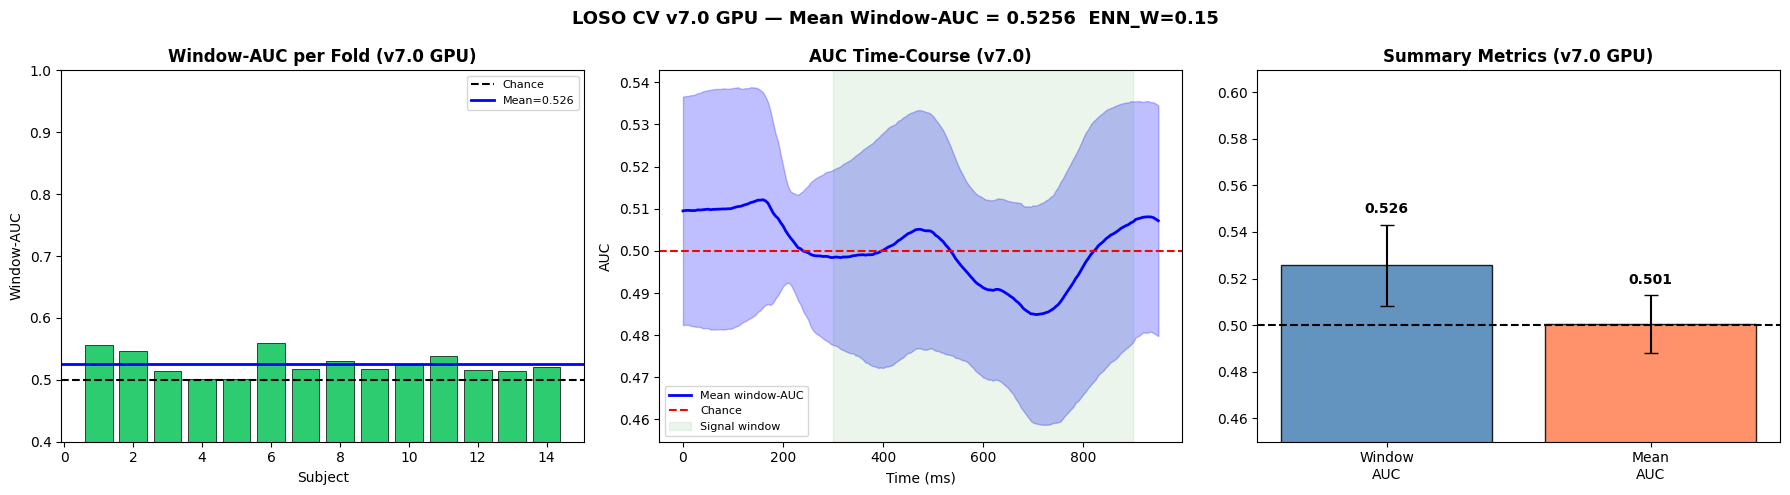

  Plot saved → D:\EEG Project\Project Overview and Specifications\eeg_competition\loso_results_v7_gpu.png

  ► Mean Window-AUC = 0.5256 ± 0.0175

STEP 4: Training final model + generating submission...

  Final Training → Submission Generation (v7.0 GPU)

Step 1: Extracting training tabular features (EA ON)...
  [1/14] S_10_cleaned ... (71400, 613)  (774.5s)
  [2/14] S_11_cleaned ... (68000, 613)  (895.2s)
  [3/14] S_13_cleaned ... (298800, 613)  (3568.6s)
  [4/14] S_14_cleaned ... (181400, 613)  (1609.8s)
  [5/14] S_15_cleaned ... (195200, 613)  (1236.1s)
  [6/14] S_16_cleaned ... (126200, 613)  (799.1s)
  [7/14] S_17_cleaned ... (143600, 613)  (908.4s)
  [8/14] S_2_cleaned ... (109400, 613)  (692.4s)
  [9/14] S_3_cleaned ... (137000, 613)  (865.9s)
  [10/14] S_4_cleaned ... (154200, 613)  (974.8s)
  [11/14] S_5_cleaned ... (112200, 613)  (711.3s)
  [12/14] S_6_cleaned ... (149000, 613)  (951.3s)
  [13/14] S_8_cleaned ... (171000, 613)  (1098.3s)
  [14/14] S_9_cleaned ... (124400, 613

  TRE training: 100%|██████████| 121/121 [08:04<00:00,  4.00s/it]


  ✓ 121 classifiers trained in 927.2s

Step 4b: Adaptive per-timepoint ensemble weights...
  ✓ Adaptive weights computed

Step 4c: Training final EEGNet on ALL training data...
  ✓ Final EEGNet trained

Step 5: Fitting isotonic calibrators on OOF predictions...
  ✓ Isotonic calibration fitted

Step 6: Generating test predictions...

  Subject 1 (test_subject_1): 372 trials
    range : [0.010, 0.990]  mean : 0.4944

  Subject 12 (test_subject_12): 883 trials
    range : [0.010, 0.990]  mean : 0.4916

  Subject 7 (test_subject_7): 479 trials
    range : [0.010, 0.990]  mean : 0.4950

✓ Submission saved → D:\EEG Project\Project Overview and Specifications\eeg_competition\Notebook_submission.csv
  Total rows : 346,800
   id  prediction
1_0_0    0.503985
1_0_1    0.504183
1_0_2    0.503372
1_0_3    0.504058
1_0_4    0.503955
1_0_5    0.503407

STEP 5: Validating submission...
  ✓ id column present
  ✓ prediction column present
  ✓ ID format: subject_trial_timepoint
  ✓ Total rows: 346,800
 

In [15]:
# Set RUN_LOSO=True to estimate Window-AUC before submitting.
# Strongly recommended: it also auto-tunes SMOOTH_SIGMA and ENN_W.
RUN_LOSO = True

print("""
╔══════════════════════════════════════════════════════════════════════════╗
║   EEG Emotional Memory — Ultra Pipeline v7.0 (GPU Edition)              ║
╠══════════════════════════════════════════════════════════════════════════╣
║  GPU-1  CatBoost   : task_type='GPU'  +  500 iterations                 ║
║  GPU-2  LightGBM   : 800 trees, 63 leaves  (GPU)                        ║
║  GPU-3  XGBoost    : 600 trees  (CUDA)                                  ║
║  GPU-4  EEGNet     : TemporalEEGNet  AMP+TF32+torch.compile             ║
║  GPU-5  Feature M  : log-Euclidean covariance  logm(C)                  ║
║  GPU-6  Memory     : torch.cuda.empty_cache() between folds             ║
║  GPU-7  RTX Ada    : TF32 + torch.compile + AMP autocast                ║
║  Features: ~615/tp | Classifiers: 121 | Ensemble: 5 models             ║
╚══════════════════════════════════════════════════════════════════════════╝
""")

total_start = time.time()

print("STEP 1: Loading training data...")
train_subjects = load_all_training(EMO_DIR, NEU_DIR)

print("\nSTEP 2: Loading test data...")
test_subjects = load_all_test(TEST_DIR)

if RUN_LOSO:
    print("\nSTEP 3: LOSO Cross-Validation (sigma + ENN_W auto-tuning)...")
    fold_results = run_loso(train_subjects, tune_sigma=True)
    win_aucs = [r['window_auc'] for r in fold_results]
    print(f"\n  ► Mean Window-AUC = {np.mean(win_aucs):.4f} ± {np.std(win_aucs):.4f}")
else:
    print("\nSTEP 3: Skipping LOSO (set RUN_LOSO=True — strongly recommended!)")
    fold_results = []

print("\nSTEP 4: Training final model + generating submission...")
df = generate_submission(train_subjects, test_subjects, OUTPUT)

print("\nSTEP 5: Validating submission...")
assert 'id'         in df.columns
assert 'prediction' in df.columns
assert df['prediction'].between(0,1).all(), "Predictions out of [0,1] range!"
parts = str(df.iloc[0]['id']).split('_')
assert len(parts) == 3, f"ID format wrong: {df.iloc[0]['id']}"
print(f"  ✓ id column present")
print(f"  ✓ prediction column present")
print(f"  ✓ ID format: subject_trial_timepoint")
print(f"  ✓ Total rows: {len(df):,}")
print(f"  ✓ Pred range: [{df.prediction.min():.4f}, {df.prediction.max():.4f}]")

print("\nSTEP 6: Copying submission to working directory...")
import shutil
local_copy = os.path.join(os.getcwd(), 'Notebook_submission.csv')  # notebook-safe (no __file__)
if os.path.abspath(OUTPUT) != os.path.abspath(local_copy):
    try:
        shutil.copy(OUTPUT, local_copy)
        print(f"  ✓ Copied to {local_copy}")
    except Exception as e:
        print(f"  ⚠ Copy skipped: {e}")
else:
    print(f"  ✓ Submission already at {OUTPUT}")

total_time = time.time() - total_start
win_summary = (f"Mean Window-AUC = {np.mean([r['window_auc'] for r in fold_results]):.4f}"
               if fold_results else "LOSO skipped — set RUN_LOSO=True before final submit")

print(f"""
╔══════════════════════════════════════════════════════════════════════════╗
║  ✓ DONE  ({total_time/60:.1f} min total)
╠══════════════════════════════════════════════════════════════════════════╣
║  {win_summary:<70s}║
║  SMOOTH_SIGMA = {SMOOTH_SIGMA:<55d}║
║  ENN_W        = {ENN_W:<55.2f}║
║  Submission: {OUTPUT:<59s}║
╚══════════════════════════════════════════════════════════════════════════╝
""")

---
## CELL 16 — Diagnostics & Utilities


In [16]:
def diagnose(path):
    """Print full HDF5 tree of a .mat file."""
    print(f"\nDiagnosing: {path}")
    with h5py.File(path, 'r') as f:
        def show(name, obj):
            sh = obj.shape if hasattr(obj,'shape') else 'group'
            dt = obj.dtype  if hasattr(obj,'dtype')  else '—'
            print(f"  {name:45s}  shape={sh}  dtype={dt}")
        f.visititems(show)

def gpu_info():
    """Print current GPU memory usage (PyTorch)."""
    if HAVE_TORCH and torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated(0) / 1e9
        reserved = torch.cuda.memory_reserved(0) / 1e9
        total    = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"GPU Memory — Allocated: {alloc:.2f} GB | "
              f"Reserved: {reserved:.2f} GB | Total: {total:.1f} GB")
    else:
        print("No CUDA device available")

# diagnose(os.path.join(EMO_DIR, 'S_2_cleaned.mat'))
# gpu_info()
print("✓ diagnose() and gpu_info() ready")
print("\n✓ EEG Ultra Pipeline v7.0 GPU — all cells defined.")
print("""
Quick-start checklist:
  1. Set BASE path (CELL 3) to your data directory
  2. Ensure PyTorch CUDA is installed:
       pip install torch --index-url https://download.pytorch.org/whl/cu121
  3. Set RUN_LOSO = True (CELL 15) before final submission
  4. Run full script — GPU status will print in CELL 1
  
RTX 5000 Ada expected speedup vs CPU (v6):
  • LightGBM  : ~3–5×  (800 trees vs 500)
  • XGBoost   : ~4–6×  (600 trees vs 350)  
  • CatBoost  : ~5–8×  (500 iter vs 300, now GPU)
  • EEGNet    : ~20×   (GPU vs hypothetical CPU)
  • Total time: v7 faster than v6 despite 5th model addition
""")

✓ diagnose() and gpu_info() ready

✓ EEG Ultra Pipeline v7.0 GPU — all cells defined.

Quick-start checklist:
  1. Set BASE path (CELL 3) to your data directory
  2. Ensure PyTorch CUDA is installed:
       pip install torch --index-url https://download.pytorch.org/whl/cu121
  3. Set RUN_LOSO = True (CELL 15) before final submission
  4. Run full script — GPU status will print in CELL 1

RTX 5000 Ada expected speedup vs CPU (v6):
  • LightGBM  : ~3–5×  (800 trees vs 500)
  • XGBoost   : ~4–6×  (600 trees vs 350)  
  • CatBoost  : ~5–8×  (500 iter vs 300, now GPU)
  • EEGNet    : ~20×   (GPU vs hypothetical CPU)
  • Total time: v7 faster than v6 despite 5th model addition

